In [286]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Load the merged dataset
df = pd.read_csv('/Users/yaswanthkanagarla/Desktop/Master_Thesis/BD_code/Battery_Diagnostics_Thesis/scripts/final_7features_state_IX.csv')

# Convert 'state' if needed
state_map = {'I': 1, 'II': 2, 'III': 3, 'IV': 4, 'V': 5, 'VI': 6, 'VII': 7, 'VIII': 8, 'IX': 9}
df['state'] = df['state'].map(state_map)


In [287]:
train_groups = [(25, 6), (25, 7), (25, 8), (25, 5), (25, 3), (25, 4), (35, 1)]
val_groups   = [(25, 2), (45, 2)]                 # validation cell(s)
test_groups  = [(25, 1), (35, 2), (45, 1)]         # final test cell(s)


In [288]:
def mask_from_groups(df, groups):
    groups = set(groups)
    return df.apply(lambda r: (r["T_C"], r["cell"]) in groups, axis=1)

train_mask = mask_from_groups(df, train_groups)
val_mask   = mask_from_groups(df, val_groups)
test_mask  = mask_from_groups(df, test_groups)

train_df = df[train_mask].copy()
val_df   = df[val_mask].copy()
test_df  = df[test_mask].copy()

print("Train:", train_df.shape, "Groups:", sorted(set(zip(train_df.T_C, train_df.cell))))
print("Val  :", val_df.shape,   "Groups:", sorted(set(zip(val_df.T_C, val_df.cell))))
print("Test :", test_df.shape,  "Groups:", sorted(set(zip(test_df.T_C, test_df.cell))))


Train: (1279, 13) Groups: [(25, 3), (25, 4), (25, 5), (25, 6), (25, 7), (25, 8), (35, 1)]
Val  : (491, 13) Groups: [(25, 2), (45, 2)]
Test : (966, 13) Groups: [(25, 1), (35, 2), (45, 1)]


In [289]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

features = ["R_s_rel","R_ct_rel","R_sei_rel","Zmag_0.1Hz_rel","C_dl_log","tail_slope","Zmag_1000Hz_rel","T_C"]#, "Zmag_100Hz_rel", "Zmag_1000Hz_rel"]
 #"tail_angle_deg", "f_peak_main", "Phase_100Hz", "Phase_0.1Hz","Phase_1000Hz","Phase_10Hz","Zmag_10Hz_rel", "Zmag_100Hz_rel", "Zmag_1000Hz_rel"]

X_train, y_train = train_df[features], train_df["SOH"]
X_val,   y_val   = val_df[features],   val_df["SOH"]
X_test,  y_test  = test_df[features],  test_df["SOH"]

rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

def metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred))
    }

print("Train:", metrics(y_train, rf.predict(X_train)))
print("Val  :", metrics(y_val,   rf.predict(X_val)))
print("Test :", metrics(y_test,  rf.predict(X_test)))


Train: {'R2': 0.999042291660306, 'MAE': 0.003072652623436001, 'RMSE': np.float64(0.006105012503368577)}
Val  : {'R2': 0.10685329453854708, 'MAE': 0.05900872398859583, 'RMSE': np.float64(0.06754181621581733)}
Test : {'R2': 0.8495422699261557, 'MAE': 0.059136017531185456, 'RMSE': np.float64(0.07042834405288817)}


In [290]:
from sklearn.ensemble import RandomForestRegressor

rf_base = RandomForestRegressor(
    n_estimators=600,
    random_state=42,
    n_jobs=-1,
    max_features="sqrt",
    min_samples_leaf=1
)

rf_base.fit(X_train, y_train)

print("Base RF")
print("Train:", metrics(y_train, rf_base.predict(X_train)))
print("Val  :", metrics(y_val,   rf_base.predict(X_val)))
print("Test :", metrics(y_test,  rf_base.predict(X_test)))


Base RF
Train: {'R2': 0.9991140151673336, 'MAE': 0.0034456094440149495, 'RMSE': np.float64(0.005871959705424145)}
Val  : {'R2': 0.5869403565127644, 'MAE': 0.0402899027268543, 'RMSE': np.float64(0.04593224972923672)}
Test : {'R2': 0.9114552676325429, 'MAE': 0.04476481557789093, 'RMSE': np.float64(0.054028335650132195)}


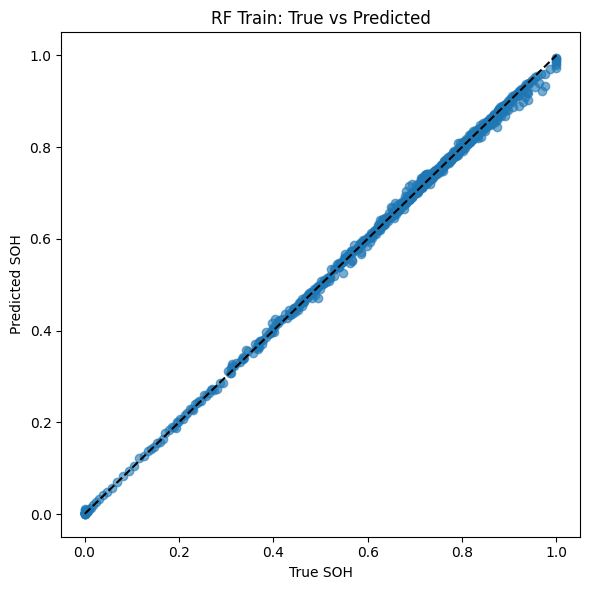

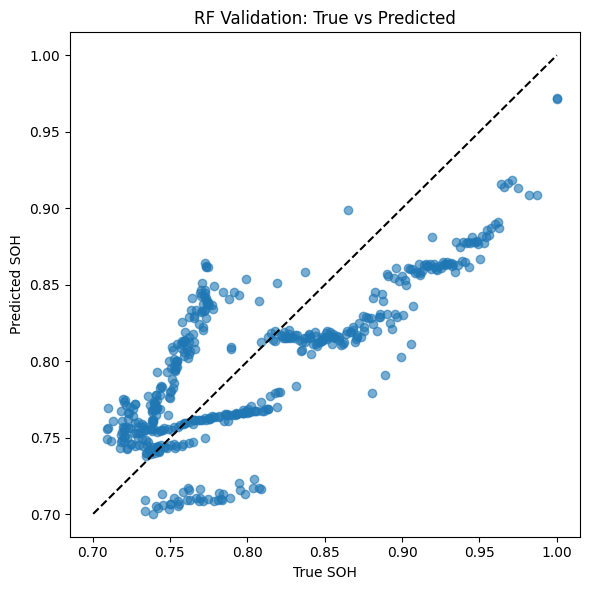

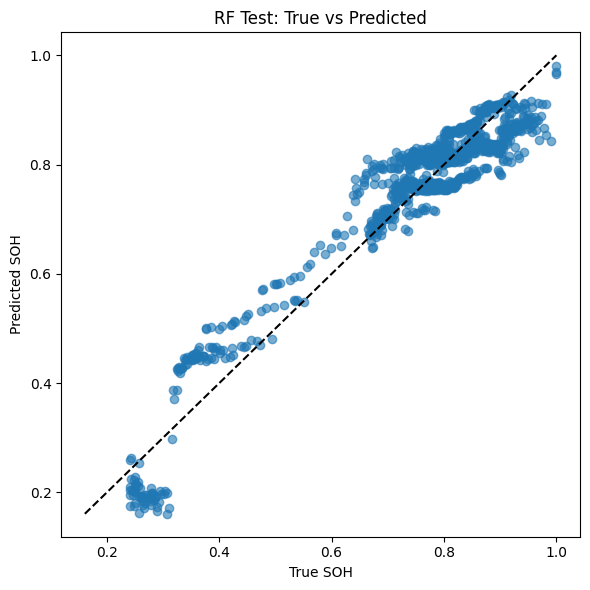

In [291]:
import matplotlib.pyplot as plt
import numpy as np

def true_vs_pred_plot(y_true, y_pred, title):
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())

    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.6)
    plt.plot([lo, hi], [lo, hi], "k--")
    plt.xlabel("True SOH")
    plt.ylabel("Predicted SOH")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Train
true_vs_pred_plot(y_train, rf_base.predict(X_train), "RF Train: True vs Predicted")

# Val
true_vs_pred_plot(y_val, rf_base.predict(X_val), "RF Validation: True vs Predicted")

# Test
true_vs_pred_plot(y_test, rf_base.predict(X_test), "RF Test: True vs Predicted")


In [292]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor

results = []
best_rmse = np.inf
best_model = None
best_params = None

for n_estimators in [300, 600, 1000]:
    for max_depth in [None, 8, 12, 16, 24]:
        for min_samples_leaf in [1, 2, 4, 8]:
            for max_features in ["sqrt", 0.5, 0.7, 1.0]:
                rf = RandomForestRegressor(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    max_features=max_features,
                    random_state=42,
                    n_jobs=-1
                )
                rf.fit(X_train, y_train)

                val_pred = rf.predict(X_val)
                rmse = float(np.sqrt(mean_squared_error(y_val, val_pred)))

                row = {
                    "n_estimators": n_estimators,
                    "max_depth": max_depth,
                    "min_samples_leaf": min_samples_leaf,
                    "max_features": max_features,
                    "val_rmse": rmse
                }
                results.append(row)

                if rmse < best_rmse:
                    best_rmse = rmse
                    best_model = rf
                    best_params = row

results_df = pd.DataFrame(results).sort_values("val_rmse")
print("Best params:", best_params)
print("Best Val RMSE:", best_rmse)
results_df.head(10)


Best params: {'n_estimators': 600, 'max_depth': 12, 'min_samples_leaf': 2, 'max_features': 0.5, 'val_rmse': 0.04371695387509895}
Best Val RMSE: 0.04371695387509895


,n_estimators,max_depth,min_samples_leaf,max_features,val_rmse
117,600,12.0,2,0.5,0.043717
149,600,24.0,2,0.5,0.043900
85,600,NaN,2,0.5,0.043900
73,300,24.0,4,0.5,0.044103
9,300,NaN,4,0.5,0.044103
57,300,16.0,4,0.5,0.044115
133,600,16.0,2,0.5,0.044184
129,600,16.0,1,0.5,0.044215
145,600,24.0,1,0.5,0.044256
137,600,16.0,4,0.5,0.044263


In [293]:
print("Tuned RF")
print("Train:", metrics(y_train, best_model.predict(X_train)))
print("Val  :", metrics(y_val,   best_model.predict(X_val)))
print("Test :", metrics(y_test,  best_model.predict(X_test)))


Tuned RF
Train: {'R2': 0.9983659150767518, 'MAE': 0.004439033715112165, 'RMSE': np.float64(0.007974569266070453)}
Val  : {'R2': 0.6258229747863877, 'MAE': 0.03944014942481928, 'RMSE': np.float64(0.043716953875098975)}
Test : {'R2': 0.8958409391885693, 'MAE': 0.048446034011478234, 'RMSE': np.float64(0.05859880398831425)}


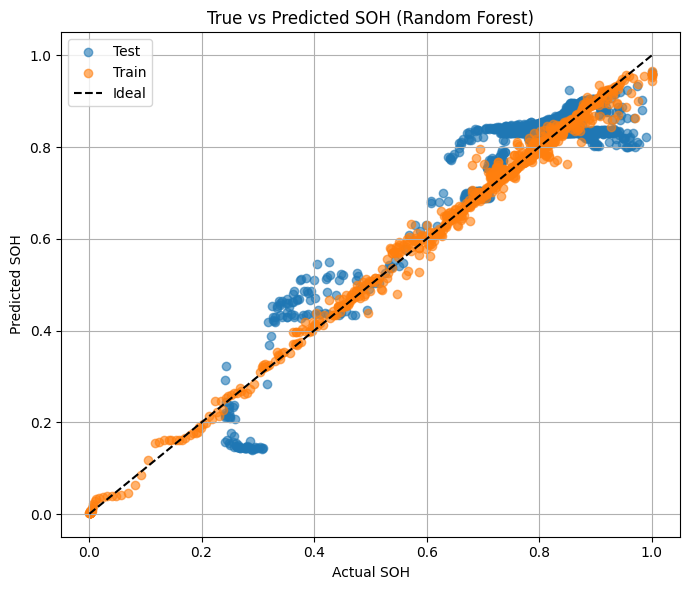

In [294]:
import matplotlib.pyplot as plt
import pandas as pd

# Predictions
y_train_pred = rf.predict(X_train)
y_test_pred  = rf.predict(X_test)

# Create plotting DataFrames
train_plot = pd.DataFrame({
    "SOH_true": y_train,
    "SOH_pred": y_train_pred,
    "set": "Train"
})

test_plot = pd.DataFrame({
    "SOH_true": y_test,
    "SOH_pred": y_test_pred,
    "set": "Test"
})

plot_df = pd.concat([train_plot, test_plot])

# Diagonal limits
min_val = min(plot_df["SOH_true"].min(), plot_df["SOH_pred"].min())
max_val = max(plot_df["SOH_true"].max(), plot_df["SOH_pred"].max())

# Plot
plt.figure(figsize=(7,6))
for s, df_s in plot_df.groupby("set"):
    plt.scatter(
        df_s["SOH_true"],
        df_s["SOH_pred"],
        label=s,
        alpha=0.6
    )

plt.plot([min_val, max_val], [min_val, max_val], "k--", label="Ideal")
plt.xlabel("Actual SOH")
plt.ylabel("Predicted SOH")
plt.title("True vs Predicted SOH (Random Forest)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Num features in X_train: 8
Num importances: 8
           feature  importance
3   Zmag_0.1Hz_rel    0.624596
6  Zmag_1000Hz_rel    0.254750
0          R_s_rel    0.047700
4         C_dl_log    0.031512
7              T_C    0.020171
1         R_ct_rel    0.011295
2        R_sei_rel    0.006124
5       tail_slope    0.003852


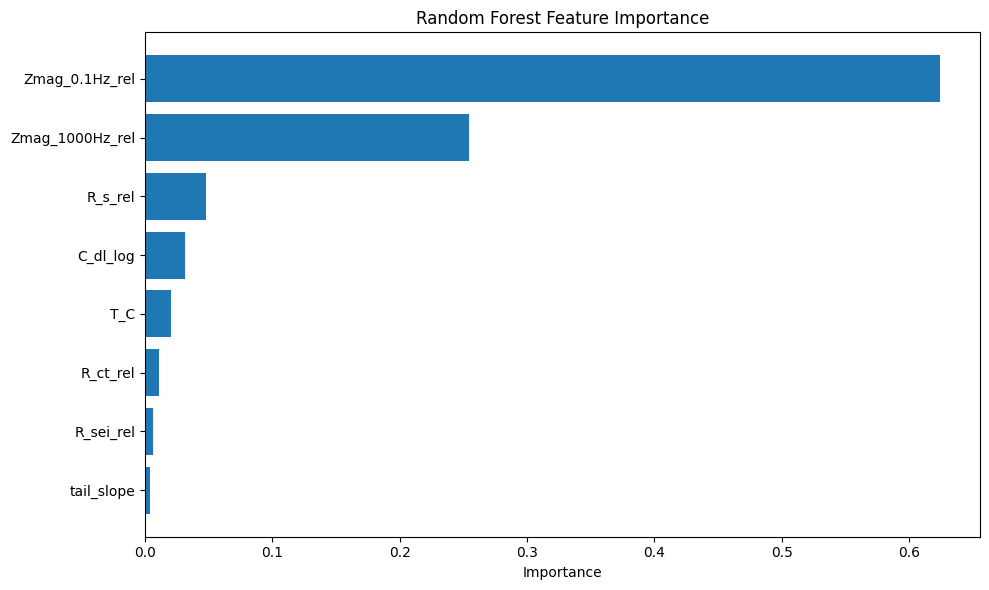

In [295]:
import pandas as pd
import matplotlib.pyplot as plt

# Use the exact columns used for training
feature_cols = list(X_train.columns)

importances = rf.feature_importances_

print("Num features in X_train:", len(feature_cols))
print("Num importances:", len(importances))

feature_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": importances
}).sort_values("importance", ascending=False)

print(feature_importance_df)

plt.figure(figsize=(10,6))
plt.barh(feature_importance_df["feature"], feature_importance_df["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()


In [296]:
import numpy as np

# X_test must be a DataFrame or numpy array
tree_preds = np.array([
    tree.predict(X_test)
    for tree in rf.estimators_
])  # shape: (n_trees, n_samples)


/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Decisio

In [297]:
y_pred_mean = tree_preds.mean(axis=0)

lower = np.percentile(tree_preds, 2.5, axis=0)
upper = np.percentile(tree_preds, 97.5, axis=0)
plot_df = test_df.copy()
plot_df = plot_df.reset_index(drop=True)

plot_df["SOH_pred"] = y_pred_mean
plot_df["SOH_lower"] = lower
plot_df["SOH_upper"] = upper



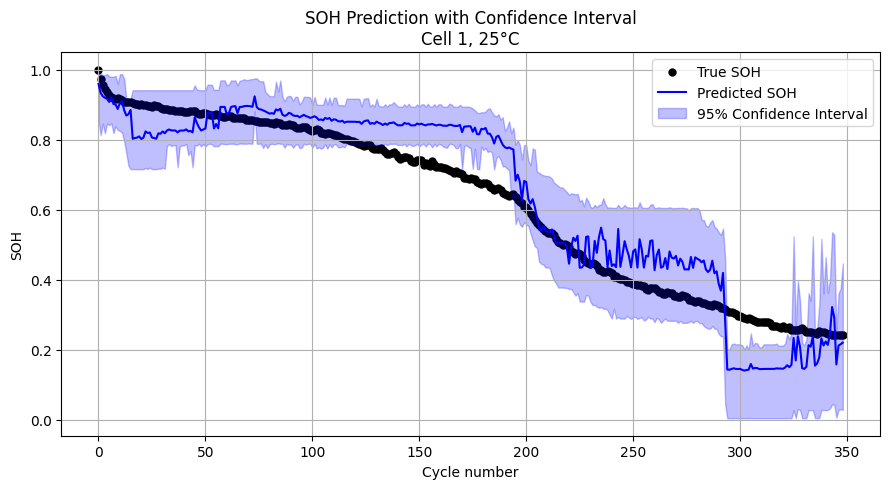

In [298]:
import matplotlib.pyplot as plt

cell_id = 1
temp = 25

df_plot = plot_df[
    (plot_df["cell"] == cell_id) &
    (plot_df["T_C"] == temp)
].sort_values("cycle")

plt.figure(figsize=(9, 5))

# True SOH
plt.scatter(
    df_plot["cycle"],
    df_plot["SOH"],
    label="True SOH",
    color="black",
    s=25
)

# Predicted SOH
plt.plot(
    df_plot["cycle"],
    df_plot["SOH_pred"],
    label="Predicted SOH",
    color="blue"
)

# Confidence band
plt.fill_between(
    df_plot["cycle"],
    df_plot["SOH_lower"],
    df_plot["SOH_upper"],
    color="blue",
    alpha=0.25,
    label="95% Confidence Interval"
)

plt.xlabel("Cycle number")
plt.ylabel("SOH")
plt.title(f"SOH Prediction with Confidence Interval\nCell {cell_id}, {temp}°C")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


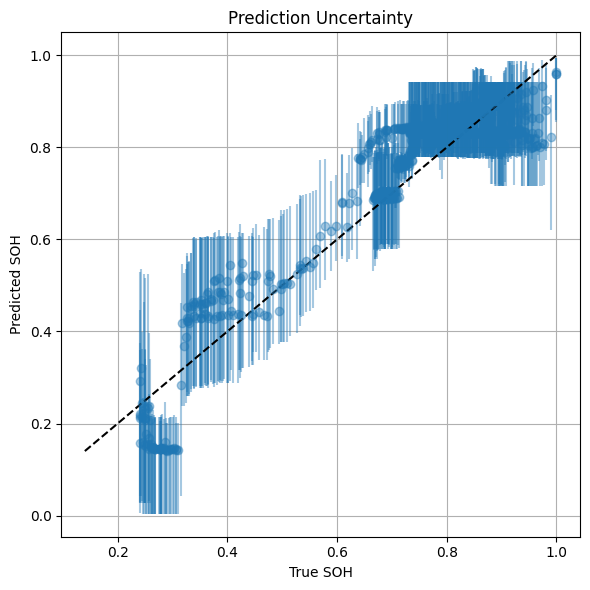

In [299]:
plt.figure(figsize=(6, 6))

plt.errorbar(
    plot_df["SOH"],
    plot_df["SOH_pred"],
    yerr=[
        plot_df["SOH_pred"] - plot_df["SOH_lower"],
        plot_df["SOH_upper"] - plot_df["SOH_pred"]
    ],
    fmt="o",
    alpha=0.4
)

min_val = min(plot_df["SOH"].min(), plot_df["SOH_pred"].min())
max_val = max(plot_df["SOH"].max(), plot_df["SOH_pred"].max())

plt.plot([min_val, max_val], [min_val, max_val], "k--")

plt.xlabel("True SOH")
plt.ylabel("Predicted SOH")
plt.title("Prediction Uncertainty")
plt.grid(True)
plt.tight_layout()
plt.show()
